# Noise Residual Stream for Deepfake Detection (EfficientNetV2-S Architecture)

This notebook implements a binary classifier using Spatial Rich Model (SRM) filters to extract noise residuals, followed by an EfficientNetV2-S backbone for spatial feature learning.

**Workflow:**
1. Load raw RGB tensors (precomputed: resize + to_tensor only)
2. Apply augmentation (H/V flips + color/JPEG compression/Blur for BOTH real and fake images) → SRM filtering on 3-channel RGB → truncate noise to [-3, 3] (NO ImageNet normalization)
3. Train EfficientNetV2-S with inverted 3-tier differential learning rates and label smoothing
4. Evaluate with comprehensive performance metrics

**Key Components:**
- **100% GPU Pipeline**: All augmentation, SRM, and truncation operations on GPU
- **SRM Filters**: Fixed 5x5 kernel that extracts high-frequency noise patterns from 3-channel RGB images
- **EfficientNetV2-S**: Pre-trained CNN backbone (all layers trainable with inverted 3-tier learning rates)
- **Symmetric Augmentations**: Color jitter and JPEG compression applied to BOTH real and fake images (50% probability), Gaussian Blur applied to BOTH real and fake images (20% probability)
- **Anti-Overfitting**: Label smoothing (0.0→0.05, 1.0→0.95) + differential learning rates

**Training Strategy:**
- **All Layers Unfrozen**: Entire model is trainable with 3-tier differential learning rates
- **Early features (blocks 0-4)**: lr=1e-4 (fast adaptation to truncated noise)
- **Late features (blocks 5+)**: lr=5e-5 (moderate adaptation of mid-to-high level features)
- **Classifier (fc)**: lr=1e-4 (aggressive training of task-specific head)

**Methodological Fixes:**
- ✓ **Symmetric Augmentations**: Prevents shortcut learning by applying color/JPEG/blur to both classes
- ✓ **3-Channel SRM**: Preserves chrominance noise artifacts (no grayscale conversion)
- ✓ **Truncation Instead of Normalization**: Respects zero-mean Laplacian noise distribution
- ✓ **EfficientNetV2-S Depthwise-Separable Convolutions**: Trained with inverted LRs to focus on high-frequency noise

**Performance Analysis:**
- Comprehensive metrics (Accuracy, Precision, Recall, F1, AUC-ROC)
- Confusion matrices and classification reports
- ROC curves and Precision-Recall curves

In [1]:
import os
import sys
import warnings
import numpy as np
from pathlib import Path
from PIL import Image
import cv2

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
from torchvision import datasets
import kornia.augmentation as K

from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix, classification_report, 
    roc_curve, auc, roc_auc_score, precision_recall_curve, 
    average_precision_score, f1_score,
    precision_score, recall_score
)

# Suppress torch.meshgrid warning from kornia's JPEG compression
warnings.filterwarnings('ignore', category=UserWarning, message='.*torch.meshgrid.*')

sys.path.append('..')
from utils.models import SRMConv2d, NoiseEfficientNet

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Step 1: Define Noise-EfficientNet Model

In [2]:
print("NoiseEfficientNet model imported successfully from utils.models!")
print("\nArchitecture:")
print("  1. RAW RGB Input (224x224) - loaded from precomputed tensors")
print("  2. GPU Augmentation: H/V flips + color/JPEG compression (50% probability for BOTH real and fake)")
print("  3. GPU SRM Filter: Fixed 5x5 filter extracts 3-channel noise residuals from RGB")
print("  4. Truncate Noise: Clamp noise residuals to [-3, 3] (NO ImageNet normalization)")
print("  5. EfficientNetV2-S: Pre-trained on ImageNet (all layers trainable)")
print("  6. Final Classifier: Dropout(0.5) + Linear(1280, 1)")
print("\nTraining Strategy:")
print("  - All layers UNFROZEN (entire model trainable)")
print("  - INVERTED 3-Tier Differential Learning Rates:")
print("    * Early features (blocks 0-4): lr=1e-4 (fast adaptation to noise)")
print("    * Late features (blocks 5+): lr=5e-5")
print("    * Classifier: lr=1e-4")
print("  - Augmentations: Color/JPEG 30% each + Gaussian Blur 20% (applied to BOTH real and fake images)")
print("  - Label Smoothing: 0.0→0.05, 1.0→0.95 (training only)")
print("  - 100% GPU Operations: Zero CPU overhead in training loop")
print("\nKey Methodological Fixes:")
print("  ✓ Symmetric augmentations prevent shortcut learning")
print("  ✓ 3-channel SRM preserves chrominance noise artifacts")
print("  ✓ Truncation respects zero-mean Laplacian noise distribution")
print("  ✓ Early layers adapt faster to noise (not RGB textures)")

NoiseEfficientNet model imported successfully from utils.models!

Architecture:
  1. RAW RGB Input (224x224) - loaded from precomputed tensors
  2. GPU Augmentation: H/V flips + color/JPEG compression (50% probability for BOTH real and fake)
  3. GPU SRM Filter: Fixed 5x5 filter extracts 3-channel noise residuals from RGB
  4. Truncate Noise: Clamp noise residuals to [-3, 3] (NO ImageNet normalization)
  5. EfficientNetV2-S: Pre-trained on ImageNet (all layers trainable)
  6. Final Classifier: Dropout(0.5) + Linear(1280, 1)

Training Strategy:
  - All layers UNFROZEN (entire model trainable)
  - INVERTED 3-Tier Differential Learning Rates:
    * Early features (blocks 0-4): lr=1e-4 (fast adaptation to noise)
    * Late features (blocks 5+): lr=5e-5
    * Classifier: lr=1e-4
  - Augmentations: Color/JPEG 30% each + Gaussian Blur 20% (applied to BOTH real and fake images)
  - Label Smoothing: 0.0→0.05, 1.0→0.95 (training only)
  - 100% GPU Operations: Zero CPU overhead in training loop



## Step 2: Precompute RAW RGB Tensors (No Normalization, No SRM)

In [3]:
# Check if precomputation is needed
output_dir = '../data/image_RGB'
if os.path.exists(output_dir) and len(os.listdir(output_dir)) > 0:
    print(f"✓ Precomputed RGB tensors already exist at {output_dir}")
    print("Skipping precomputation step.")
else:
    print("Starting RGB tensor precomputation...")
    print("Note: Saving RAW RGB tensors (no normalization, no SRM filtering)")
    
    # Define preprocessing transforms - ONLY resize and convert to tensor
    preprocess = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])
    
    # Define source and target directories
    splits = ['train', 'val', 'test']
    classes = ['fake', 'real']
    
    input_base = '../data/image'
    output_base = '../data/image_RGB'
    
    # Create output directories
    for split in splits:
        for cls in classes:
            os.makedirs(os.path.join(output_base, split, cls), exist_ok=True)
    
    # Process each split
    total_processed = 0
    for split in splits:
        print(f"\nProcessing {split} set...")
        
        for cls in classes:
            input_dir = os.path.join(input_base, split, cls)
            output_dir_cls = os.path.join(output_base, split, cls)
            
            # Skip if directory doesn't exist
            if not os.path.exists(input_dir):
                print(f"  Warning: {input_dir} does not exist, skipping...")
                continue
            
            # Get all image files
            image_files = [f for f in os.listdir(input_dir) 
                          if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]
            
            print(f"  Processing {len(image_files)} {cls} images...")
            
            for img_file in tqdm(image_files, desc=f"  {split}/{cls}"):
                # Load and preprocess image
                img_path = os.path.join(input_dir, img_file)
                img = Image.open(img_path).convert('RGB')
                img_tensor = preprocess(img)  # Only resize + to_tensor (no normalization)
                
                # Save as .pt file
                output_path = os.path.join(output_dir_cls, 
                                          os.path.splitext(img_file)[0] + '.pt')
                torch.save(img_tensor, output_path)
                
                total_processed += 1
    
    print(f"\n✓ Precomputation complete! Processed {total_processed} images.")
    print(f"✓ Raw RGB tensors saved to {output_base}")

✓ Precomputed RGB tensors already exist at ../data/image_RGB
Skipping precomputation step.


## Step 3: Define Custom Dataset for Precomputed RGB Tensors

In [4]:
from utils.dataset import PrecomputedSRMDataset

# Create datasets (now loading RAW RGB tensors)
print("\n=== Creating Datasets ===")
train_dataset = PrecomputedSRMDataset('../data/image_RGB/train')
val_dataset = PrecomputedSRMDataset('../data/image_RGB/val')
test_dataset = PrecomputedSRMDataset('../data/image_RGB/test')

print("\n=== Dataset Summary ===")
print(f"Train: {len(train_dataset)} images")
print(f"Validation: {len(val_dataset)} images")
print(f"Test: {len(test_dataset)} images")


=== Creating Datasets ===
Loaded 27960 precomputed RGB tensors from ../data/image_RGB/train
  Fake (Class 0): 13990
  Real (Class 1): 13970
Loaded 5991 precomputed RGB tensors from ../data/image_RGB/val
  Fake (Class 0): 2996
  Real (Class 1): 2995
Loaded 5981 precomputed RGB tensors from ../data/image_RGB/test
  Fake (Class 0): 2992
  Real (Class 1): 2989

=== Dataset Summary ===
Train: 27960 images
Validation: 5991 images
Test: 5981 images


## Step 4: Create DataLoaders

In [5]:
# Hyperparameters
BATCH_SIZE = 64
NUM_EPOCHS = 50

# Create dataloaders with pin_memory for faster GPU transfer
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True if torch.cuda.is_available() else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True if torch.cuda.is_available() else False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True if torch.cuda.is_available() else False
)

print(f'\n=== DataLoaders Created ===')
print(f'Train batches: {len(train_loader)}')
print(f'Validation batches: {len(val_loader)}')
print(f'Test batches: {len(test_loader)}')


=== DataLoaders Created ===
Train batches: 437
Validation batches: 94
Test batches: 94


## Step 5: Define Evaluation Metrics Functions

In [6]:
def compute_detailed_metrics(model, data_loader, device, srm_layer, dataset_name="Dataset"):
    """
    Compute comprehensive evaluation metrics including:
    - Accuracy, Precision, Recall, F1-Score
    - Confusion Matrix
    - ROC-AUC and Precision-Recall AUC
    - Per-class performance
    
    Label Convention: Dataset uses Fake=0, Real=1
    Prediction Convention: Model predicts with Fake=0 as positive class for deepfake detection
    
    Key Changes:
    - NO grayscale conversion - SRM processes 3-channel RGB directly
    - NO ImageNet normalization - truncate noise residuals to [-3, 3]
    - Inverted labels/predictions to treat Fake (0) as positive class
    """
    model.eval()
    srm_layer.eval()
    all_labels = []
    all_preds = []
    all_probs = []
    
    with torch.no_grad():
        for inputs, labels in tqdm(data_loader, desc=f"Evaluating {dataset_name}"):
            # Move to GPU
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True).float()
            
            # Scale to [0, 255] range for SRM processing
            inputs = inputs * 255.0
            
            # GPU Extract Noise from 3-channel RGB (NO grayscale conversion)
            inputs = srm_layer(inputs)
            
            # Truncate noise residuals to [-3, 3]
            inputs = torch.clamp(inputs, min=-3.0, max=3.0)
            
            # Normalize to [-1, 1] range for EfficientNetV2-S
            inputs = inputs / 3.0
            
            # GPU Forward Pass (3-channel noise map)
            outputs = model(inputs).squeeze(1)
            
            # Model outputs logits where high value = Real (1), low value = Fake (0)
            # Compute probability of Real class
            probs_real = torch.sigmoid(outputs)
            # Predict Real (1) if P(Real) > 0.5, else Fake (0)
            preds = (probs_real > 0.5).float()
            
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs_real.cpu().numpy())
    
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)
    
    # Convert to treat Fake (0) as positive class
    labels_fake_positive = (all_labels == 0).astype(int)
    fake_probs = 1.0 - all_probs  # Convert P(Real) to P(Fake)
    
    # Calculate metrics with Fake=0 as positive class
    accuracy = (all_preds == all_labels).mean()  # Accuracy is class-agnostic
    precision = precision_score(all_labels, all_preds, pos_label=0, zero_division=0)
    recall = recall_score(all_labels, all_preds, pos_label=0, zero_division=0)
    f1 = f1_score(all_labels, all_preds, pos_label=0, zero_division=0)
    
    cm = confusion_matrix(all_labels, all_preds)
    
    fpr, tpr, _ = roc_curve(labels_fake_positive, fake_probs)
    roc_auc = auc(fpr, tpr)
    
    precision_curve, recall_curve, _ = precision_recall_curve(labels_fake_positive, fake_probs)
    pr_auc = average_precision_score(labels_fake_positive, fake_probs)
    
    metrics = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'confusion_matrix': cm,
        'fpr': fpr,
        'tpr': tpr,
        'precision_curve': precision_curve,
        'recall_curve': recall_curve,
        'predictions': all_preds,
        'labels': all_labels,
        'probabilities': all_probs
    }
    
    return metrics


def print_performance_summary(metrics, dataset_name="Dataset"):
    """Print a formatted summary of performance metrics."""
    print(f"\n{'='*60}")
    print(f"{dataset_name.upper()} PERFORMANCE SUMMARY")
    print(f"{'='*60}")
    print(f"Accuracy:       {metrics['accuracy']*100:.2f}%")
    print(f"Precision:      {metrics['precision']*100:.2f}%")
    print(f"Recall:         {metrics['recall']*100:.2f}%")
    print(f"F1-Score:       {metrics['f1_score']*100:.2f}%")
    print(f"ROC-AUC:        {metrics['roc_auc']:.4f}")
    print(f"PR-AUC:         {metrics['pr_auc']:.4f}")
    print(f"{'='*60}")
    
    cm = metrics['confusion_matrix']
    # CM format: [[Fake->Fake, Fake->Real], [Real->Fake, Real->Real]]
    fake_tp, fake_fn, fake_fp, fake_tn = cm.ravel()
    
    print(f"\nConfusion Matrix (Fake as Positive Class):")
    print(f"  True Positives (Fake → Fake):    {fake_tp:5d}")
    print(f"  False Positives (Real → Fake):   {fake_fp:5d}")
    print(f"  False Negatives (Fake → Real):   {fake_fn:5d}")
    print(f"  True Negatives (Real → Real):    {fake_tn:5d}")
    
    # Sensitivity (Recall) = TP / (TP + FN) = correctly detected fakes / all fakes
    sensitivity = fake_tp / (fake_tp + fake_fn) if (fake_tp + fake_fn) > 0 else 0
    # Specificity = TN / (TN + FP) = correctly identified reals / all reals
    specificity = fake_tn / (fake_tn + fake_fp) if (fake_tn + fake_fp) > 0 else 0
    
    print(f"\nPer-Class Performance:")
    print(f"  Fake Images (Class 0 - Positive Class):")
    print(f"    - Correctly classified: {fake_tp}/{fake_tp+fake_fn} ({sensitivity*100:.2f}%)")
    print(f"    - Misclassified as Real: {fake_fn}")
    print(f"  Real Images (Class 1 - Negative Class):")
    print(f"    - Correctly classified: {fake_tn}/{fake_tn+fake_fp} ({specificity*100:.2f}%)")
    print(f"    - Misclassified as Fake: {fake_fp}")
    print(f"{'='*60}\n")


def plot_roc_curves(train_metrics, val_metrics, test_metrics):
    """Plot ROC curves for all datasets."""
    plt.figure(figsize=(10, 8))
    
    datasets = [
        ('Training', train_metrics, 'blue'),
        ('Validation', val_metrics, 'green'),
        ('Test', test_metrics, 'red')
    ]
    
    for name, metrics, color in datasets:
        plt.plot(metrics['fpr'], metrics['tpr'], 
                color=color, lw=2, 
                label=f"{name} (AUC = {metrics['roc_auc']:.4f})")
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (Real classified as Fake)', fontsize=12)
    plt.ylabel('True Positive Rate (Fake detected as Fake)', fontsize=12)
    plt.title('ROC Curves - Deepfake Detection (Fake as Positive Class)', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=11)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

print("✓ Comprehensive metrics functions defined!")

✓ Comprehensive metrics functions defined!


## Step 6: Training and Validation Functions (100% GPU Pipeline)

In [7]:
# Global GPU Setup: Instantiate SRM layer (processes 3-channel RGB input)
srm_layer = SRMConv2d(in_channels=3).to(device)  # 3 channels for RGB
srm_layer.eval()  # Fixed weights, no gradient

def train_epoch(model, train_loader, criterion, optimizer, device, srm_layer, scaler):
    """
    Train the model for one epoch with 100% GPU operations.

    Label Convention: Dataset uses Fake=0, Real=1
    Model outputs logits where high value = Real (1), low value = Fake (0)

    Key Changes:
    - ColorJitter and JPEG p=0.3 each + Gaussian Blur p=0.2 (applied to BOTH real and fake images)
    - NO grayscale conversion - SRM processes 3-channel RGB directly
    - NO ImageNet normalization - truncate noise residuals to [-3, 3]

    Uses AMP (autocast + GradScaler) for improved throughput/stability.
    """
    from torch.amp import autocast

    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    # Instantiate augmentations on GPU (applied directly without masking)
    color_aug = K.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5).to(device)
    jpeg_aug = K.RandomJPEG(jpeg_quality=(50.0, 90.0), p=0.5).to(device)
    blur_aug = K.RandomGaussianBlur(kernel_size=(3, 3), sigma=(0.1, 0.5), p=0.2).to(device)

    amp_enabled = scaler is not None and scaler.is_enabled()

    pbar = tqdm(train_loader, desc='Training')
    for inputs, labels in pbar:
        # a. Move to GPU fast
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True).float()

        # b. GPU Spatial Augmentations (H/V flips)
        h_mask = torch.rand(inputs.size(0), 1, 1, 1, device=device) < 0.5
        inputs = torch.where(h_mask, torch.flip(inputs, dims=[3]), inputs)

        v_mask = torch.rand(inputs.size(0), 1, 1, 1, device=device) < 0.5
        inputs = torch.where(v_mask, torch.flip(inputs, dims=[2]), inputs)

        # c. Apply Augmentations to BOTH real and fake images (30% probability handled by p=0.3)
        inputs = color_aug(inputs)
        inputs = jpeg_aug(inputs)
        inputs = blur_aug(inputs)

        # d. Scale to [0, 255] range for SRM processing
        inputs = inputs * 255.0

        # e. GPU Extract Noise from 3-channel RGB (NO grayscale conversion)
        # SRM processes each RGB channel independently -> output: (B, 3, H, W)
        inputs = srm_layer(inputs)

        # f. Truncate noise residuals (zero-mean Laplacian) to [-3, 3]
        inputs = torch.clamp(inputs, min=-3.0, max=3.0)

        # g. Normalize to [-1, 1] range for EfficientNetV2-S
        inputs = inputs / 3.0

        # h. GPU Forward Pass (3-channel noise map)
        optimizer.zero_grad(set_to_none=True)

        # Apply label smoothing (1.0 -> 0.95, 0.0 -> 0.05)
        smoothed_labels = labels * 0.9 + 0.05

        device_type = 'cuda' if device.type == 'cuda' else 'cpu'
        with autocast(device_type, enabled=amp_enabled):
            outputs = model(inputs).squeeze(1)
            loss = criterion(outputs, smoothed_labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * inputs.size(0)

        # For accuracy: predict Real (1) if P(Real) > 0.5, else Fake (0)
        probs_real = torch.sigmoid(outputs.float())
        preds = (probs_real > 0.5).float()

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{100 * correct / total:.2f}%'})

    return running_loss / total, correct / total


def validate_epoch(model, val_loader, criterion, device, srm_layer):
    """
    Validate the model for one epoch with 100% GPU operations.
    
    Label Convention: Dataset uses Fake=0, Real=1
    Model outputs logits where high value = Real (1), low value = Fake (0)
    AUC calculated with Fake=0 as positive class (consistent with evaluation)
    
    Key Changes:
    - NO grayscale conversion - SRM processes 3-channel RGB directly
    - NO ImageNet normalization - truncate noise residuals to [-3, 3]
    """
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        pbar = tqdm(val_loader, desc='Validation')
        for inputs, labels in pbar:
            # a. Move to GPU fast
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True).float()
            
            # b. Scale to [0, 255] range for SRM processing
            inputs = inputs * 255.0
            
            # c. GPU Extract Noise from 3-channel RGB (NO grayscale conversion)
            inputs = srm_layer(inputs)
            
            # d. Truncate noise residuals to [-3, 3]
            inputs = torch.clamp(inputs, min=-3.0, max=3.0)
            
            # e. Normalize to [-1, 1] range for EfficientNetV2-S 
            inputs = inputs / 3.0
            
            # f. GPU Forward Pass (3-channel noise map)
            outputs = model(inputs).squeeze(1)
            
            # Compute loss (no label smoothing during validation)
            loss = criterion(outputs, labels)
            
            # Compute probability of Real class (positive class)
            probs_real = torch.sigmoid(outputs)
            preds = (probs_real > 0.5).float()
            
            running_loss += loss.item() * inputs.size(0)
            
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
            # Store probabilities and labels for AUC calculation
            all_probs.extend(probs_real.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())
            
            pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{100 * correct / total:.2f}%'})
    
    # Calculate AUC with Fake as positive class (consistent with evaluation)
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    fake_probs = 1.0 - all_probs  # Convert P(Real) to P(Fake)
    labels_fake_positive = (all_labels == 0).astype(int)  # Treat Fake as positive
    epoch_auc = roc_auc_score(labels_fake_positive, fake_probs)
    
    return running_loss / total, correct / total, epoch_auc

print("✓ Training and validation functions defined with 100% GPU pipeline!")
print("✓ Key methodological fixes applied:")
print("  - Augmentations: Color/JPEG 30% each + Gaussian Blur 20% (applied to BOTH real and fake images)")
print("  - NO grayscale conversion - SRM processes 3-channel RGB directly")
print("  - NO ImageNet normalization - truncate noise residuals to [-3, 3]")

print("✓ Training and validation functions defined with 100% GPU pipeline!")
print("✓ All preprocessing operations run on GPU for maximum throughput")

✓ Training and validation functions defined with 100% GPU pipeline!
✓ Key methodological fixes applied:
  - Augmentations: Color/JPEG 30% each + Gaussian Blur 20% (applied to BOTH real and fake images)
  - NO grayscale conversion - SRM processes 3-channel RGB directly
  - NO ImageNet normalization - truncate noise residuals to [-3, 3]
✓ Training and validation functions defined with 100% GPU pipeline!
✓ All preprocessing operations run on GPU for maximum throughput


## Step 7: Training Loop with Final Test Evaluation

Initializing fresh model, optimizer, and scheduler...
✓ All layers unfrozen - entire model is trainable
✓ INVERTED 3-Tier Differential Learning Rates:
  - Early features (blocks 0-4): lr=1e-4 (fast adaptation to noise)
  - Late features (blocks 5+): lr=5e-5
  - Classifier: lr=1e-4

Starting training with 100% GPU-accelerated pipeline...

Epoch 1/50
--------------------------------------------------


Training: 100%|██████████| 437/437 [01:43<00:00,  4.23it/s, loss=0.5931, acc=65.73%]


Train Loss: 0.6263, Train Acc: 65.73%


Validation: 100%|██████████| 94/94 [00:30<00:00,  3.11it/s, loss=0.4658, acc=74.23%]


Val Loss: 0.5150, Val Acc: 74.23%, Val AUC: 0.8266
Best model saved (val_auc: 0.8266)

Epoch 2/50
--------------------------------------------------


...

Val Loss: 0.2698, Val Acc: 89.70%, Val AUC: 0.9567

Early stopping triggered after 32 epochs!

Training completed!
Best model at epoch 22 with val_auc: 0.9611
Model saved to: ..\saved_models\best_noise_efficientnet.pth

Loading best model weights for final evaluation...
✓ Best model loaded from epoch 22

FINAL TEST SET EVALUATION


Evaluating Test: 100%|██████████| 94/94 [00:32<00:00,  2.92it/s]



TEST PERFORMANCE SUMMARY
Accuracy:       90.00%
Precision:      89.66%
Recall:         90.44%
F1-Score:       90.05%
ROC-AUC:        0.9622
PR-AUC:         0.9622

Confusion Matrix (Fake as Positive Class):
  True Positives (Fake → Fake):     2706
  False Positives (Real → Fake):     312
  False Negatives (Fake → Real):     286
  True Negatives (Real → Real):     2677

Per-Class Performance:
  Fake Images (Class 0 - Positive Class):
    - Correctly classified: 2706/2992 (90.44%)
    - Misclassified as Real: 286
  Real Images (Class 1 - Negative Class):
    - Correctly classified: 2677/2989 (89.56%)
    - Misclassified as Fake: 312


Computing training and validation metrics for comparison...


Evaluating Validation: 100%|██████████| 94/94 [00:29<00:00,  3.22it/s]


TRAINING PERFORMANCE SUMMARY
Accuracy:       99.02%
Precision:      99.49%
Recall:         98.55%
F1-Score:       99.02%
ROC-AUC:        0.9994
PR-AUC:         0.9994

Confusion Matrix (Fake as Positive Class):
  True Positives (Fake → Fake):    13787
  False Positives (Real → Fake):      71
  False Negatives (Fake → Real):     203
  True Negatives (Real → Real):    13899

Per-Class Performance:
  Fake Images (Class 0 - Positive Class):
    - Correctly classified: 13787/13990 (98.55%)
    - Misclassified as Real: 203
  Real Images (Class 1 - Negative Class):
    - Correctly classified: 13899/13970 (99.49%)
    - Misclassified as Fake: 71


VALIDATION PERFORMANCE SUMMARY
Accuracy:       90.17%
Precision:      90.32%
Recall:         89.99%
F1-Score:       90.15%
ROC-AUC:        0.9611
PR-AUC:         0.9576

Confusion Matrix (Fake as Positive Class):
  True Positives (Fake → Fake):     2696
  False Positives (Real → Fake):     289
  False Negatives (Fake → Real):     300
  True Negative

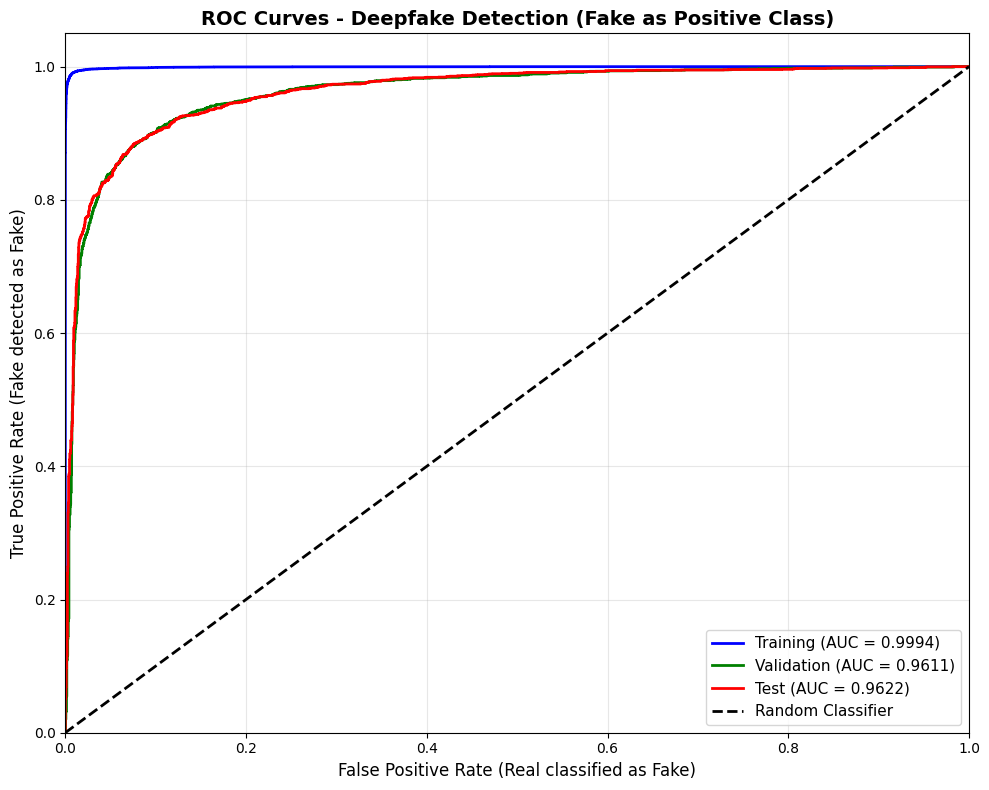

In [8]:
def main():
    print('Initializing fresh model, optimizer, and scheduler...')
    
    # 1. INSTANTIATE MODEL FRESH EVERY TIME (ALL LAYERS UNFROZEN)
    model = NoiseEfficientNet().to(device)
    
    print('✓ All layers unfrozen - entire model is trainable')
    print('✓ INVERTED 3-Tier Differential Learning Rates:')
    print('  - Early features (blocks 0-4): lr=1e-4 (fast adaptation to noise)')
    print('  - Late features (blocks 5+): lr=5e-5')
    print('  - Classifier: lr=1e-4')
    
    # 2. SETUP OPTIMIZER & SCHEDULER FRESH EVERY TIME
    criterion = nn.BCEWithLogitsLoss()

    # AMP gradient scaler for mixed precision training
    scaler = torch.amp.GradScaler('cuda', enabled=(device.type == 'cuda'))
    
    # INVERTED 3-Tier Differential Learning Rates
    # Early layers need to adapt faster to truncated noise (not RGB textures)
    early_features_params = []
    late_features_params = []
    
    for i, block in enumerate(model.efficientnet.features):
        if i <= 4:
            early_features_params.extend(list(block.parameters()))
        else:
            late_features_params.extend(list(block.parameters()))
    
    # Decoupled weight decay (AdamW best practices)
    # - No weight decay on 1D params (bias, BatchNorm/LayerNorm weights)
    # - Weight decay on standard 2D+ params
    weight_decay = 0.05

    def split_decay_no_decay(param_list):
        decay_params = []
        no_decay_params = []
        for p in param_list:
            if p.ndim <= 1:
                no_decay_params.append(p)
            else:
                decay_params.append(p)
        return decay_params, no_decay_params

    early_decay, early_no_decay = split_decay_no_decay(early_features_params)
    late_decay, late_no_decay = split_decay_no_decay(late_features_params)

    classifier_params = list(model.efficientnet.classifier.parameters())
    classifier_decay, classifier_no_decay = split_decay_no_decay(classifier_params)

    param_groups = []

    # Early features: lr=1e-4
    if len(early_decay) > 0:
        param_groups.append({'params': early_decay, 'lr': 1e-4, 'weight_decay': weight_decay})
    if len(early_no_decay) > 0:
        param_groups.append({'params': early_no_decay, 'lr': 1e-4, 'weight_decay': 0.0})

    # Late features: lr=5e-5
    if len(late_decay) > 0:
        param_groups.append({'params': late_decay, 'lr': 5e-5, 'weight_decay': weight_decay})
    if len(late_no_decay) > 0:
        param_groups.append({'params': late_no_decay, 'lr': 5e-5, 'weight_decay': 0.0})

    # Classifier: lr=1e-4
    if len(classifier_decay) > 0:
        param_groups.append({'params': classifier_decay, 'lr': 1e-4, 'weight_decay': weight_decay})
    if len(classifier_no_decay) > 0:
        param_groups.append({'params': classifier_no_decay, 'lr': 1e-4, 'weight_decay': 0.0})

    optimizer = optim.AdamW(param_groups, weight_decay=0.0)
    
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=10, T_mult=2, eta_min=1e-6
    )

    # 3. SETUP SAVING DIRECTORIES
    save_dir = Path('../saved_models')
    save_dir.mkdir(parents=True, exist_ok=True)
    best_model_path = save_dir / 'best_noise_efficientnet.pth'

    # 4. RESET TRAINING HISTORY
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_auc': []}
    best_val_auc = 0.0
    best_epoch = 0

    print('\nStarting training with 100% GPU-accelerated pipeline...\n')

    early_stop_patience = 10
    epochs_no_improve = 0

    for epoch in range(NUM_EPOCHS):
        print(f'Epoch {epoch+1}/{NUM_EPOCHS}')
        print('-' * 50)
        
        # Train (no mean/std arguments)
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device, srm_layer, scaler)
        print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}%')
        
        # Validate (no mean/std arguments)
        val_loss, val_acc, val_auc = validate_epoch(model, val_loader, criterion, device, srm_layer)
        print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc*100:.2f}%, Val AUC: {val_auc:.4f}')
        
        # Save history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_auc'].append(val_auc)
        
        # Learning rate scheduler step (cosine annealing)
        scheduler.step()
        
        # Save best model based on AUC
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_epoch = epoch + 1
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': val_loss,
                'val_acc': val_acc,
                'val_auc': val_auc,
            }, best_model_path)
            print(f'Best model saved (val_auc: {val_auc:.4f})')
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
        
        if epochs_no_improve >= early_stop_patience:
            print(f'\nEarly stopping triggered after {epoch+1} epochs!')
            break
        
        print()

    print(f'\nTraining completed!')
    print(f'Best model at epoch {best_epoch} with val_auc: {best_val_auc:.4f}')
    print(f'Model saved to: {best_model_path}')
    
    # Load best model weights
    print(f'\nLoading best model weights for final evaluation...')
    model.load_state_dict(torch.load(best_model_path)['model_state_dict'])
    print(f'✓ Best model loaded from epoch {best_epoch}')
    
    # Final Test Evaluation (no mean/std arguments)
    print(f'\n{"="*80}')
    print(f'FINAL TEST SET EVALUATION')
    print(f'{"="*80}')
    
    test_metrics = compute_detailed_metrics(model, test_loader, device, srm_layer, "Test")
    print_performance_summary(test_metrics, "Test")
    
    # Compute train and val metrics for comparison (no mean/std arguments)
    print(f'\nComputing training and validation metrics for comparison...')
    train_metrics = compute_detailed_metrics(model, train_loader, device, srm_layer, "Train")
    val_metrics = compute_detailed_metrics(model, val_loader, device, srm_layer, "Validation")
    
    print_performance_summary(train_metrics, "Training")
    print_performance_summary(val_metrics, "Validation")
    
    # Plot ROC curves
    plot_roc_curves(train_metrics, val_metrics, test_metrics)
    
    return history, best_model_path, train_metrics, val_metrics, test_metrics

if __name__ == '__main__':
    history, best_model_path, train_metrics, val_metrics, test_metrics = main()

## Step 8: Visualize Training History

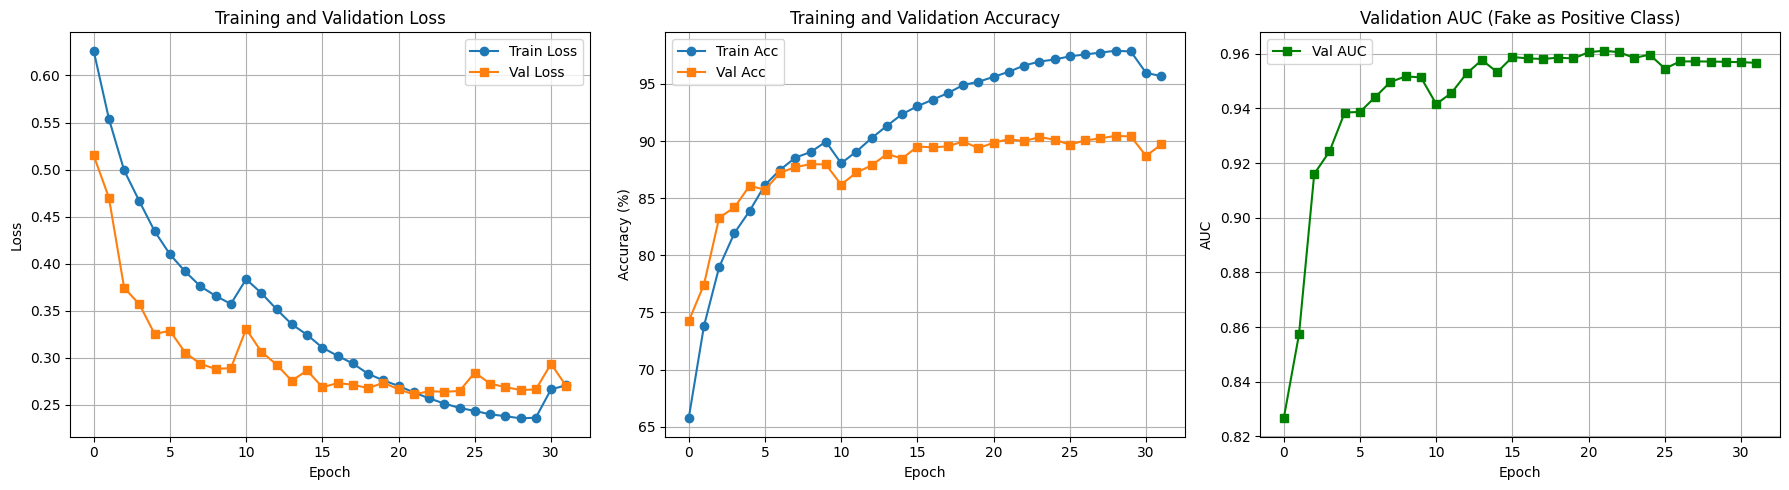

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot loss
axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(history['val_loss'], label='Val Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Plot accuracy
axes[1].plot([acc * 100 for acc in history['train_acc']], label='Train Acc', marker='o')
axes[1].plot([acc * 100 for acc in history['val_acc']], label='Val Acc', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

# Plot AUC
axes[2].plot(history['val_auc'], label='Val AUC', marker='s', color='green')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUC')
axes[2].set_title('Validation AUC (Fake as Positive Class)')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

## Step 9: Evaluation by Manipulation Type

In [10]:
import re
from collections import defaultdict
from pathlib import Path
import time

def extract_manipulation_type(filepath):
    """
    Extract manipulation type from file path or filename.
    
    Optimized version with cached type lists and early returns.
    
    Supported types:
    - FaceForensics++: Deepfakes, Face2Face, FaceSwap, NeuralTextures, FaceShifter
    - ArtiFact: progan, stylegan, stargan, sfhq, face_synthetics, stable-diffusion
    - Real (3 types): CelebA-HQ, FFHQ, FF++ C23
    
    Returns:
        str: Manipulation type (e.g., 'CelebA-HQ', 'Deepfakes', 'progan', etc.)
    """
    filepath = str(filepath).replace('\\', '/')
    filepath_lower = filepath.lower()
    filename = Path(filepath).stem.lower()
    
    # Type mappings (defined once as function attribute for caching)
    if not hasattr(extract_manipulation_type, '_type_map'):
        extract_manipulation_type._ffpp_types = ['deepfakes', 'face2face', 'faceswap', 'neuraltextures', 'faceshifter']
        extract_manipulation_type._artifact_types = ['stylegan', 'stargan', 'sfhq', 'face_synthetics', 'stable-diffusion']
        extract_manipulation_type._type_display = {
            'deepfakes': 'Deepfakes', 'face2face': 'Face2Face', 'faceswap': 'FaceSwap',
            'neuraltextures': 'NeuralTextures', 'faceshifter': 'FaceShifter',
            'progan': 'progan', 'stylegan': 'stylegan', 'stargan': 'stargan',
            'sfhq': 'sfhq', 'face_synthetics': 'face_synthetics', 'stable-diffusion': 'stable-diffusion'
        }
        extract_manipulation_type._type_map = True
    
    # Check if real image
    if '/real/' in filepath_lower:
        if 'celebahq' in filename:
            return 'CelebA-HQ'
        elif 'ffhq' in filename:
            return 'FFHQ'
        elif filename.startswith('real_') and '_' in filename[5:8]:
            return 'FF++ C23'
        else:
            # Unknown real types are from FF++ C23 (YouTube videos)
            return 'FF++ C23'
    
    # Check if fake image
    if '/fake/' in filepath_lower:
        for manip_type in extract_manipulation_type._ffpp_types + extract_manipulation_type._artifact_types:
            if manip_type in filename:
                return extract_manipulation_type._type_display.get(manip_type, manip_type)
        return 'Unknown'
    
    return 'Unknown'

def evaluate_by_manipulation_type_from_predictions(file_paths, predictions, labels):
    """
    Optimized evaluation by manipulation type using pre-computed predictions.
    
    This ensures consistency with the main test evaluation by reusing the same predictions.
    
    Args:
        file_paths: List of file paths for test samples
        predictions: Pre-computed predictions from test evaluation
        labels: Ground truth labels from test evaluation
        
    Returns:
        dict: Dictionary with manipulation types as keys and performance metrics as values
    """
    import time
    start_time = time.time()
    
    num_samples = len(file_paths)
    print(f"Analyzing {num_samples} test samples by manipulation type...")
    
    # Convert to numpy if needed
    if not isinstance(predictions, np.ndarray):
        predictions = np.array(predictions)
    if not isinstance(labels, np.ndarray):
        labels = np.array(labels)
    
    # Extract manipulation types (vectorized)
    print("Mapping samples to manipulation types...")
    manip_types = [extract_manipulation_type(fp) for fp in file_paths]
    
    # Group by manipulation type using numpy masks (vectorized, much faster)
    unique_types = list(set(manip_types))
    manip_results = {}
    
    manip_types_array = np.array(manip_types)
    for manip_type in unique_types:
        mask = (manip_types_array == manip_type)
        manip_results[manip_type] = {
            'labels': labels[mask],
            'preds': predictions[mask]
        }
    
    total_time = time.time() - start_time
    print(f"Analysis completed in {total_time:.2f}s")
    
    return manip_results

def print_manipulation_type_results(manip_results):
    """
    Print formatted results by manipulation type.
    
    Args:
        manip_results: Dictionary with manipulation types and their predictions
    """
    ff_types = ['Deepfakes', 'Face2Face', 'FaceSwap', 'NeuralTextures', 'FaceShifter']
    artifact_types = ['stylegan', 'stargan', 'sfhq', 'face_synthetics', 'stable-diffusion']
    real_types = ['CelebA-HQ', 'FFHQ', 'FF++ C23']
    
    print("=" * 80)
    print("EVALUATION RESULTS BY MANIPULATION TYPE")
    print("=" * 80)
    print()
    
    print(f"{'Category':<25} {'Total':<12} {'Correct':<12} {'Accuracy (%)':<15}")
    print("-" * 80)
    
    # Real images
    print("Real Images:")
    print("-" * 80)
    
    real_total = 0
    real_correct = 0
    
    for manip_type in real_types:
        if manip_type in manip_results:
            labels = manip_results[manip_type]['labels']
            preds = manip_results[manip_type]['preds']
            
            total = len(labels)
            correct = np.sum(preds == labels)
            acc = 100.0 * correct / total if total > 0 else 0.0
            
            real_total += total
            real_correct += correct
            
            print(f"{'  ' + manip_type:<25} {total:<12} {correct:<12} {acc:.2f}")
    
    print()
    
    # FaceForensics++ fakes
    print("FaceForensics++ Fakes:")
    print("-" * 80)
    
    ff_total = 0
    ff_correct = 0
    
    for manip_type in ff_types:
        if manip_type in manip_results:
            labels = manip_results[manip_type]['labels']
            preds = manip_results[manip_type]['preds']
            
            total = len(labels)
            correct = np.sum(preds == labels)
            acc = 100.0 * correct / total if total > 0 else 0.0
            
            ff_total += total
            ff_correct += correct
            
            print(f"{'  ' + manip_type:<25} {total:<12} {correct:<12} {acc:.2f}")
    
    print()
    
    # ArtiFact fakes
    print("ArtiFact Fakes:")
    print("-" * 80)
    
    artifact_total = 0
    artifact_correct = 0
    
    for manip_type in artifact_types:
        if manip_type in manip_results:
            labels = manip_results[manip_type]['labels']
            preds = manip_results[manip_type]['preds']
            
            total = len(labels)
            correct = np.sum(preds == labels)
            acc = 100.0 * correct / total if total > 0 else 0.0
            
            artifact_total += total
            artifact_correct += correct
            
            print(f"{'  ' + manip_type:<25} {total:<12} {correct:<12} {acc:.2f}")
    
    print("-" * 80)
    
    # Overall statistics
    overall_total = real_total + ff_total + artifact_total
    overall_correct = real_correct + ff_correct + artifact_correct
    overall_acc = 100.0 * overall_correct / overall_total if overall_total > 0 else 0.0
    
    print(f"{'OVERALL':<25} {overall_total:<12} {overall_correct:<12} {overall_acc:.2f}")
    print("=" * 80)
    
    # Print any unclassified manipulation types
    all_known = set(real_types + ff_types + artifact_types)
    unknown_types = set(manip_results.keys()) - all_known
    
    if unknown_types:
        print()
        print("Unknown/Other Manipulation Types:")
        print("-" * 80)
        for manip_type in sorted(unknown_types):
            labels = manip_results[manip_type]['labels']
            preds = manip_results[manip_type]['preds']
            
            total = len(labels)
            correct = np.sum(preds == labels)
            acc = 100.0 * correct / total if total > 0 else 0.0
            
            print(f"{'  ' + manip_type:<25} {total:<12} {correct:<12} {acc:.2f}")
        print("=" * 80)

# Run evaluation by manipulation type using pre-computed predictions
# This ensures consistency with the test accuracy reported above
manip_results = evaluate_by_manipulation_type_from_predictions(
    test_dataset.samples, 
    test_metrics['predictions'], 
    test_metrics['labels']
)

# Debug: Print first few filenames to verify extraction works
print("\nDebug: Sample file paths and extracted types:")
for i, filepath in enumerate(test_dataset.samples[:10]):
    manip_type = extract_manipulation_type(filepath)
    print(f"  {i+1}. {Path(filepath).name} -> {manip_type}")
print()

print_manipulation_type_results(manip_results)

Analyzing 5981 test samples by manipulation type...
Mapping samples to manipulation types...
Analysis completed in 0.02s

Debug: Sample file paths and extracted types:
  1. fake_Deepfakes_850_764_frame0000.pt -> Deepfakes
  2. fake_Deepfakes_850_764_frame0001.pt -> Deepfakes
  3. fake_Deepfakes_851_552_frame0000.pt -> Deepfakes
  4. fake_Deepfakes_851_552_frame0001.pt -> Deepfakes
  5. fake_Deepfakes_852_834_frame0000.pt -> Deepfakes
  6. fake_Deepfakes_852_834_frame0001.pt -> Deepfakes
  7. fake_Deepfakes_853_863_frame0000.pt -> Deepfakes
  8. fake_Deepfakes_853_863_frame0001.pt -> Deepfakes
  9. fake_Deepfakes_854_747_frame0000.pt -> Deepfakes
  10. fake_Deepfakes_854_747_frame0001.pt -> Deepfakes

EVALUATION RESULTS BY MANIPULATION TYPE

Category                  Total        Correct      Accuracy (%)   
--------------------------------------------------------------------------------
Real Images:
--------------------------------------------------------------------------------
  Cele